<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learning/blob/main/FP_Growth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

DATASET INFORMATION

Dataset Shape:
(7501, 20)

First 5 Rows:
              0          1           2                 3             4   \
0         shrimp    almonds     avocado    vegetables mix  green grapes   
1        burgers  meatballs        eggs               NaN           NaN   
2        chutney        NaN         NaN               NaN           NaN   
3         turkey    avocado         NaN               NaN           NaN   
4  mineral water       milk  energy bar  whole wheat rice     green tea   

                 5     6               7             8             9   \
0  whole weat flour  yams  cottage cheese  energy drink  tomato juice   
1               NaN   NaN             NaN           NaN           NaN   
2               NaN   NaN             NaN           NaN           NaN   
3               NaN   NaN             NaN           NaN           NaN   
4               NaN   NaN             NaN           NaN           NaN   

               10         11     12     13      

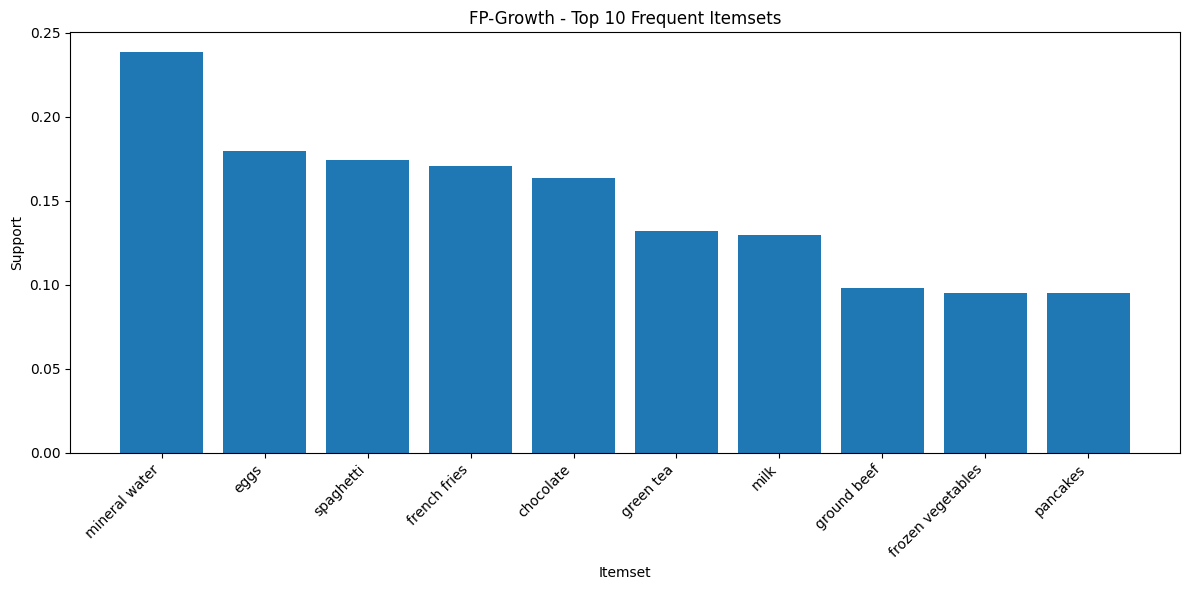

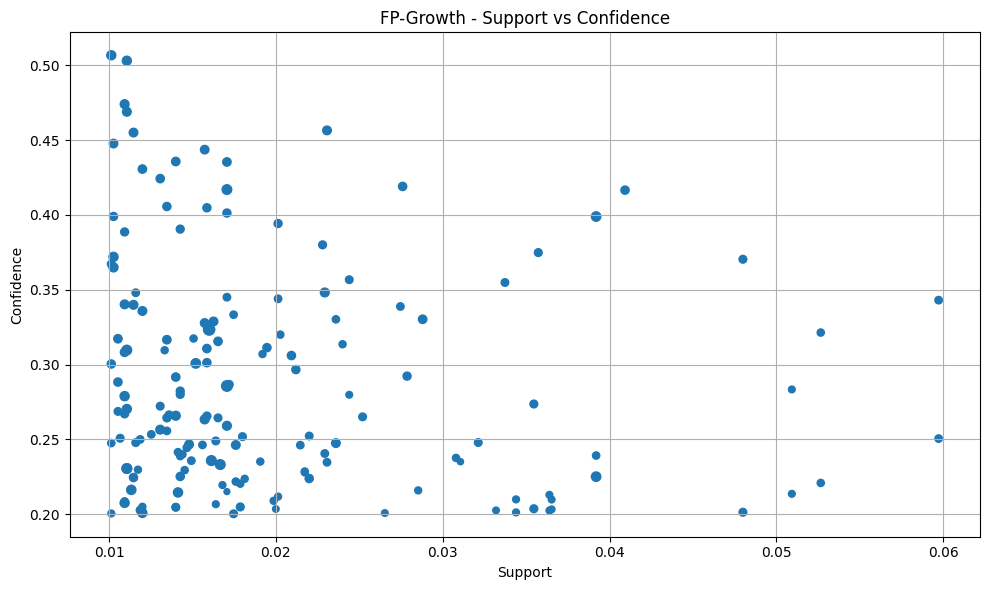

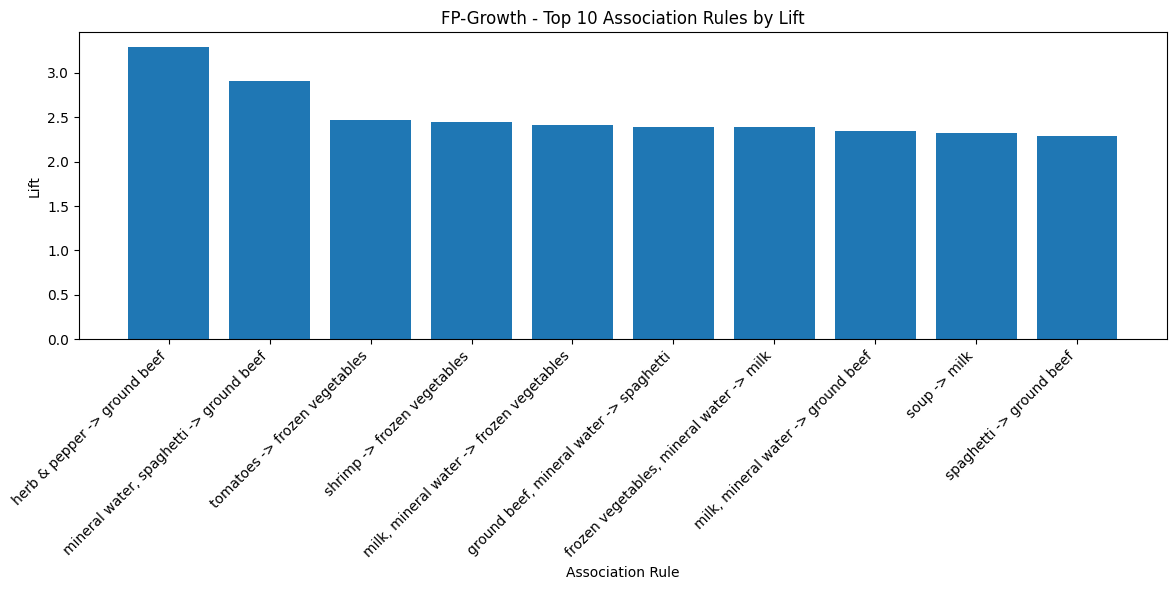

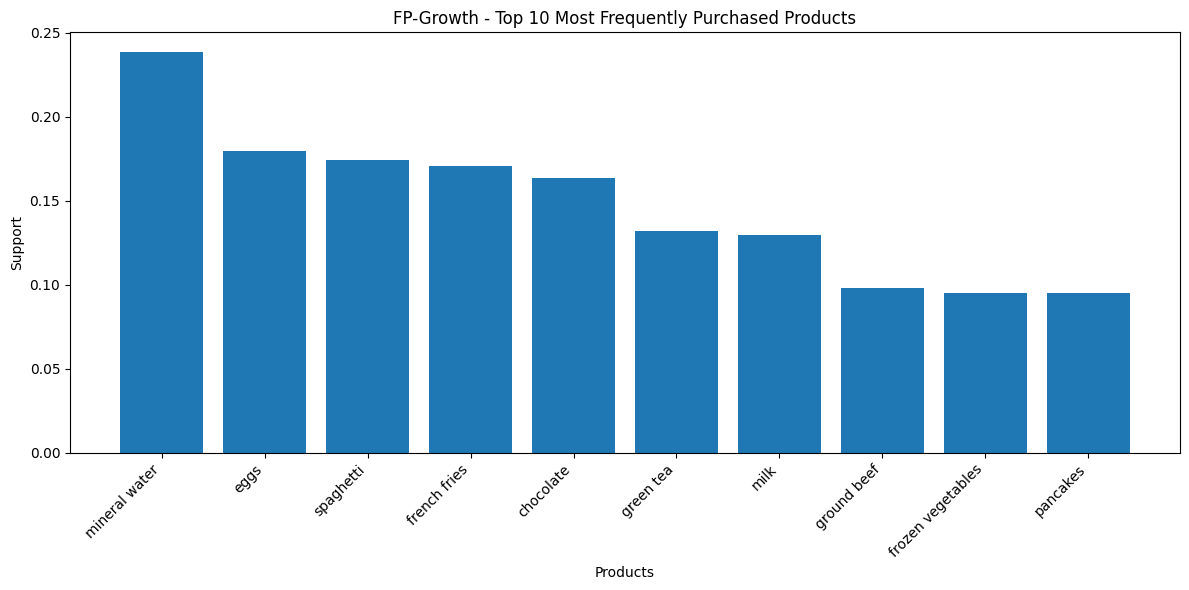


FP-GROWTH ANALYSIS COMPLETED

Frequent Itemsets saved as:
fp_growth_frequent_itemsets.csv

Association Rules saved as:
fp_growth_association_rules.csv

Graphs generated:
1. Top 10 Frequent Itemsets
2. Support vs Confidence
3. Top 10 Association Rules by Lift
4. Top 10 Most Frequently Purchased Products


In [2]:
# ============================================================
# FP-GROWTH MARKET BASKET ANALYSIS
# Retail Market Basket Transactions Dataset
# ============================================================

import warnings

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning
)

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import (
    fpgrowth,
    association_rules
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv(
    "Market_Basket_Optimisation.csv",
    header=None
)

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. CREATE TRANSACTIONS
# ============================================================

transactions = []

for i in range(len(df)):

    transaction = []

    for item in df.iloc[i]:

        if pd.notna(item):

            item = str(item).strip()

            if item != "":
                transaction.append(item)

    transactions.append(transaction)


print("\nTotal Transactions:")
print(len(transactions))


# ============================================================
# 3. FIND UNIQUE ITEMS
# ============================================================

unique_items = set()

for transaction in transactions:

    for item in transaction:
        unique_items.add(item)

unique_items = sorted(unique_items)

print("\nTotal Unique Items:")
print(len(unique_items))


# ============================================================
# 4. CREATE ONE-HOT ENCODED DATASET
# ============================================================

basket = pd.DataFrame(
    False,
    index=range(len(transactions)),
    columns=unique_items
)

for i, transaction in enumerate(transactions):

    for item in transaction:

        basket.loc[i, item] = True


print("\nOne-Hot Encoded Dataset:")
print(basket.head())


# ============================================================
# 5. APPLY FP-GROWTH
# ============================================================

print("\n" + "=" * 70)
print("FP-GROWTH ALGORITHM")
print("=" * 70)

frequent_itemsets = fpgrowth(
    basket,
    min_support=0.01,
    use_colnames=True
)


# ============================================================
# 6. DISPLAY FREQUENT ITEMSETS
# ============================================================

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

print("\nNumber of Frequent Itemsets:")
print(len(frequent_itemsets))

print("\nTop 20 Frequent Itemsets:")

print(
    frequent_itemsets.head(20)
)


# ============================================================
# 7. CREATE ASSOCIATION RULES
# ============================================================

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)


print("\n" + "=" * 70)
print("ASSOCIATION RULES")
print("=" * 70)


if len(rules) > 0:

    rules = rules.sort_values(
        by="lift",
        ascending=False
    )

    print(
        rules[
            [
                "antecedents",
                "consequents",
                "support",
                "confidence",
                "lift"
            ]
        ].head(20)
    )

else:

    print("No association rules found.")


# ============================================================
# GRAPH 1
# TOP 10 FREQUENT ITEMSETS
# ============================================================

top_items = frequent_itemsets.head(10).copy()

top_items["Itemset"] = (
    top_items["itemsets"]
    .apply(
        lambda x: ", ".join(
            sorted(list(x))
        )
    )
)


plt.figure(figsize=(12, 6))

plt.bar(
    top_items["Itemset"],
    top_items["support"]
)

plt.xlabel("Itemset")

plt.ylabel("Support")

plt.title(
    "FP-Growth - Top 10 Frequent Itemsets"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 2
# SUPPORT VS CONFIDENCE
# ============================================================

if len(rules) > 0:

    plt.figure(figsize=(10, 6))

    plt.scatter(
        rules["support"],
        rules["confidence"],
        s=rules["lift"] * 20
    )

    plt.xlabel("Support")

    plt.ylabel("Confidence")

    plt.title(
        "FP-Growth - Support vs Confidence"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.show()


# ============================================================
# GRAPH 3
# TOP 10 ASSOCIATION RULES BY LIFT
# ============================================================

if len(rules) > 0:

    top_rules = rules.head(10).copy()

    top_rules["Rule"] = (
        top_rules["antecedents"]
        .apply(
            lambda x: ", ".join(
                sorted(list(x))
            )
        )
        +
        " -> "
        +
        top_rules["consequents"]
        .apply(
            lambda x: ", ".join(
                sorted(list(x))
            )
        )
    )


    plt.figure(figsize=(12, 6))

    plt.bar(
        top_rules["Rule"],
        top_rules["lift"]
    )

    plt.xlabel(
        "Association Rule"
    )

    plt.ylabel(
        "Lift"
    )

    plt.title(
        "FP-Growth - Top 10 Association Rules by Lift"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# GRAPH 4
# TOP 10 MOST PURCHASED PRODUCTS
# ============================================================

item_support = (
    basket.mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)


plt.figure(figsize=(12, 6))

plt.bar(
    item_support.index,
    item_support.values
)

plt.xlabel(
    "Products"
)

plt.ylabel(
    "Support"
)

plt.title(
    "FP-Growth - Top 10 Most Frequently Purchased Products"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. SAVE FREQUENT ITEMSETS
# ============================================================

frequent_itemsets.to_csv(
    "fp_growth_frequent_itemsets.csv",
    index=False
)


# ============================================================
# 9. SAVE ASSOCIATION RULES
# ============================================================

if len(rules) > 0:

    rules.to_csv(
        "fp_growth_association_rules.csv",
        index=False
    )


# ============================================================
# 10. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("FP-GROWTH ANALYSIS COMPLETED")
print("=" * 70)

print(
    "\nFrequent Itemsets saved as:"
)

print(
    "fp_growth_frequent_itemsets.csv"
)

if len(rules) > 0:

    print(
        "\nAssociation Rules saved as:"
    )

    print(
        "fp_growth_association_rules.csv"
    )

print("\nGraphs generated:")
print("1. Top 10 Frequent Itemsets")
print("2. Support vs Confidence")
print("3. Top 10 Association Rules by Lift")
print("4. Top 10 Most Frequently Purchased Products")